# Tarea Semanal 0

---

### Teoría de Circuitos II

#### Alumno
Juan Manuel Miranda Del Valle

#### Institución
Universidad Tecnologica Nacional

#### Profesores
Mariano Llamedo Soria y César Fouco

#### Consignas


<img src="Captura de pantalla 2026-04-16 181307.png" width="700">

### 1.
<img src="Screenshot_20260416-195508.png" width="700">

### Transferencia 

$$
H(S) = \frac{S - \frac{R2}{C1.R3.R1}}{S + \frac{1}{C1.R3}}
$$
La naturaleza del filtro la determinan R2/R1, si tomamos R2=R1.

Con Wo dada por:

$$
Wo = \frac{1}{C1.R3}
$$

Con 

$ R3=10000\Omega $

$ C1=100nF  $
 
$ Wo=1000 s^{-1}  $



(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

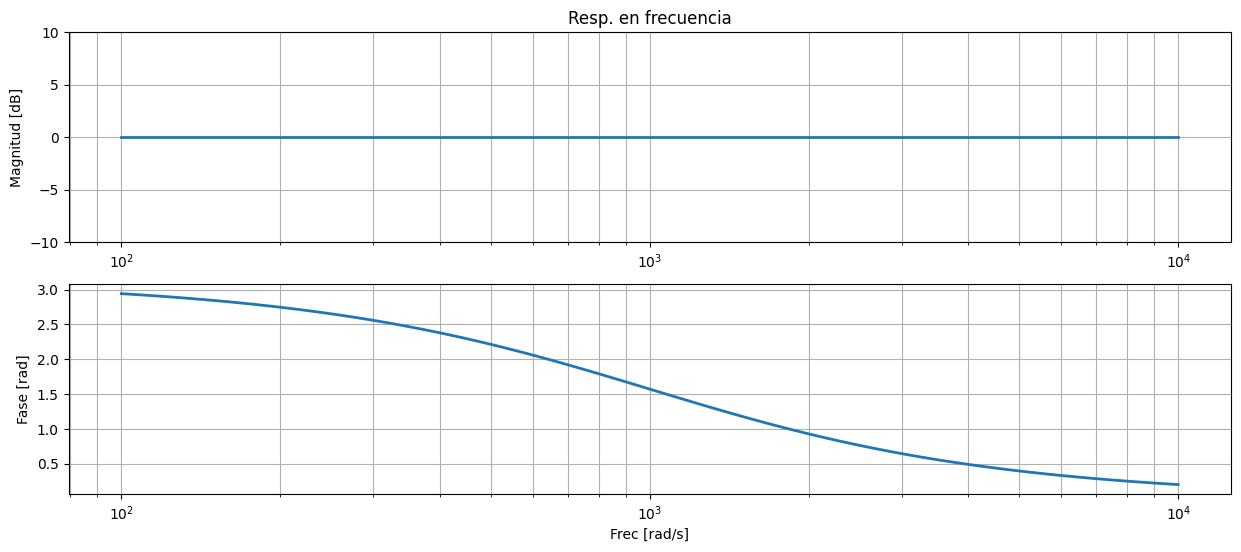

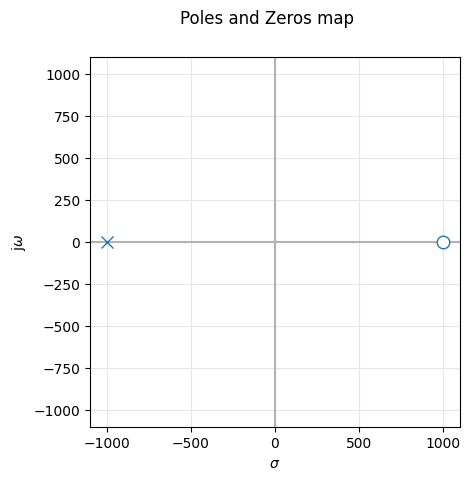

In [1]:
# Librerías externas NumPy, SciPy y Matplotlib
import scipy.signal as sig
import matplotlib.pyplot as plt
import numpy as np


# Librería de TC2, esta la vas a usar mucho
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys
Wo= 1000

H = sig.lti( [1,-Wo], [1, Wo] )
w , mag , fase =  sig.bode(H)
fase=fase*(np.pi/180)
fig , (modulo, phase)= plt.subplots(2,1,figsize=(15, 6))

modulo.semilogx(w,mag, linewidth=2)
modulo.set_title("Resp. en frecuencia")
modulo.set_ylabel("Magnitud [dB]")
modulo.set_ylim(-10,10)
modulo.grid(True, which="both")

phase.semilogx(w,fase,linewidth=2)
phase.set_xlabel("Frec [rad/s]")
phase.set_ylabel("Fase [rad]")
phase.grid(True, which="both")


pzmap(H) #S plane pole/zero plot

### Si R2 es mas grande que R1

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

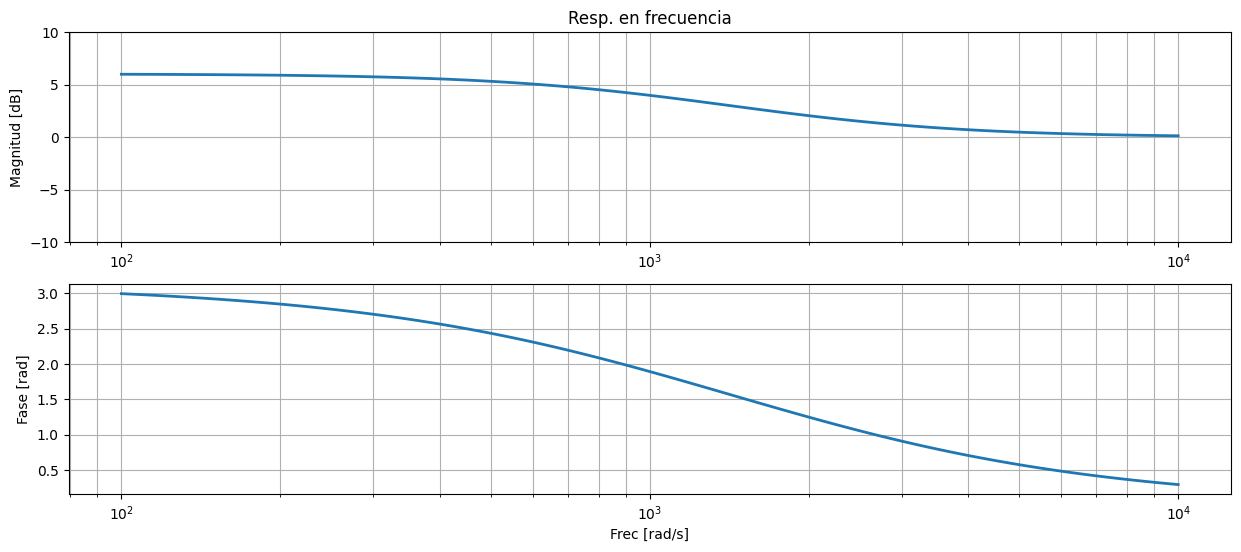

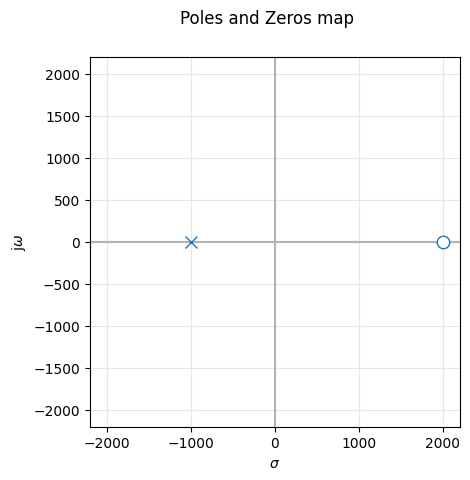

In [2]:
Wo= 1000

H = sig.lti( [1,-2*Wo], [1, Wo] )
w , mag , fase =  sig.bode(H)
fase=fase*(np.pi/180)
fig , (modulo, phase)= plt.subplots(2,1,figsize=(15, 6))

modulo.semilogx(w,mag, linewidth=2)
modulo.set_title("Resp. en frecuencia")
modulo.set_ylabel("Magnitud [dB]")
modulo.set_ylim(-10,10)
modulo.grid(True, which="both")

phase.semilogx(w,fase,linewidth=2)
phase.set_xlabel("Frec [rad/s]")
phase.set_ylabel("Fase [rad]")
phase.grid(True, which="both")


pzmap(H) #S plane pole/zero plot

### Si R2 es menor que R1

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

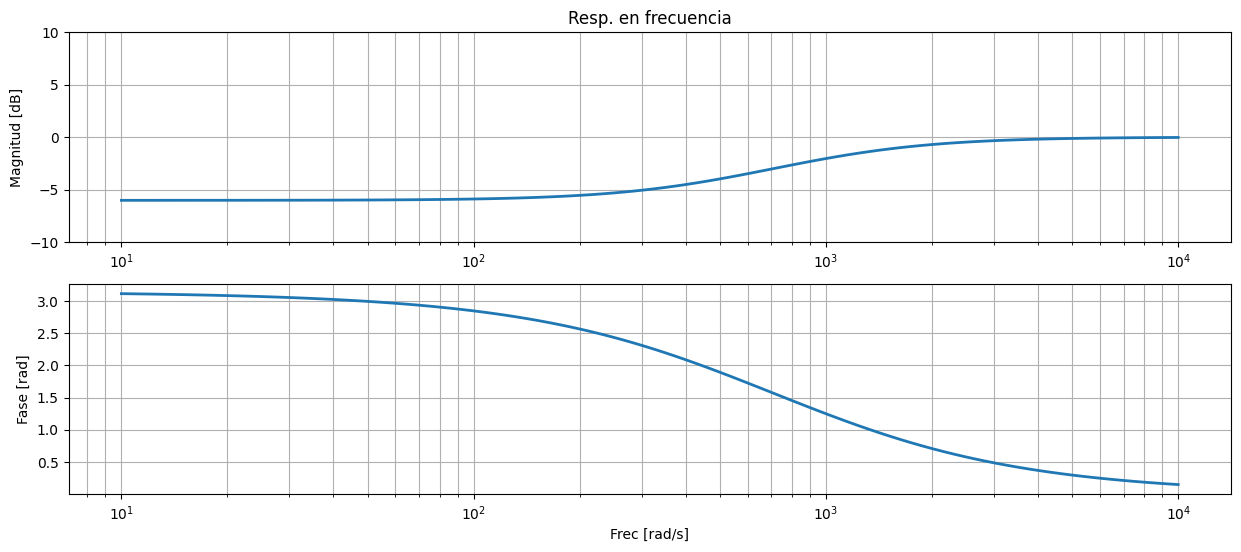

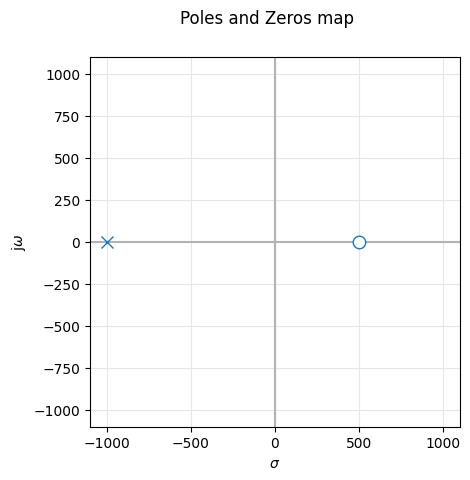

In [3]:
Wo= 1000

H = sig.lti( [1,-Wo/2], [1, Wo] )
w , mag , fase =  sig.bode(H)
fase=fase*(np.pi/180)
fig , (modulo, phase)= plt.subplots(2,1,figsize=(15, 6))

modulo.semilogx(w,mag, linewidth=2)
modulo.set_title("Resp. en frecuencia")
modulo.set_ylabel("Magnitud [dB]")
modulo.set_ylim(-10,10)
modulo.grid(True, which="both")

phase.semilogx(w,fase,linewidth=2)
phase.set_xlabel("Frec [rad/s]")
phase.set_ylabel("Fase [rad]")
phase.grid(True, which="both")


pzmap(H) #S plane pole/zero plot

## 2.

<img src="Screenshot_20260418-121106.png" width="700">

### Transferencia normalizada

$$
H(S) = \frac{S - 1}{S + 1}
$$

### 3.

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

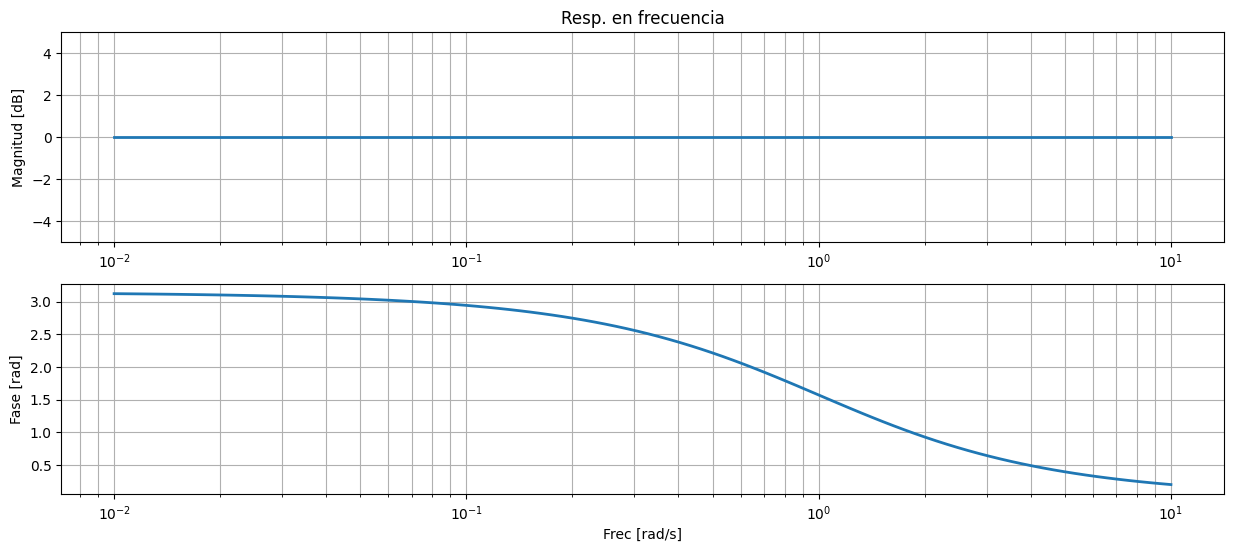

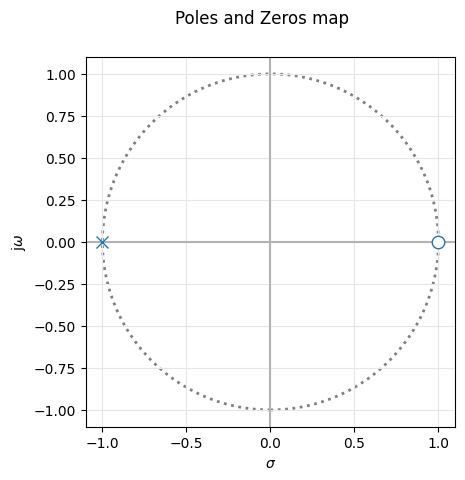

In [8]:


H = sig.lti( [1,-1], [1, 1] )
w , mag , fase =  sig.bode(H)
fase=fase*(np.pi/180)
fig , (modulo, phase)= plt.subplots(2,1,figsize=(15, 6))

modulo.semilogx(w,mag, linewidth=2)
modulo.set_title("Resp. en frecuencia")
modulo.set_ylabel("Magnitud [dB]")
modulo.set_ylim(-5,5)
modulo.grid(True, which="both")

phase.semilogx(w,fase,linewidth=2)
phase.set_xlabel("Frec [rad/s]")
phase.set_ylabel("Fase [rad]")
phase.grid(True, which="both")


pzmap(H) #S plane pole/zero plot

### 4. Simulacion en Spice

<img src="Captura de pantalla 2026-04-18 133812.png" width="700">


<img src="Captura de pantalla 2026-04-18 134032.png" width="700">

### 5. 
La parte que mas parecida veo es esta
<img src="Captura de pantalla 2026-04-18 174209.png" width="700">

Es la parte mas parecida pero porque esta el C17 va a comportarse como un pasabanda.
<img src="Captura de pantalla 2026-04-18 175306.png" width="900">


## Bonus 1

<img src="Screenshot_20260418-175534.png" width="700">

## Bonus 2


In [13]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import  print_latex, s
from pytc2.sistemas_lineales import bodePlot

import sympy as sp

# Declaro Variables
s = sp.symbols('s')
R1, R2, R3, C1 = sp.symbols('R1 R2 R3 C1')
V1, V2, Vp, Vm = sp.symbols('V1 V2 Vp Vm')

# Impedancia del capacitor
Zc = 1/(s*C1)

# --- Nodo V+ (divisor RC) ---
# (V1 - Vp)/Zc = Vp/R3
eq_vp = (V1 - Vp)/Zc - Vp/R3

# --- Nodo V- ---
# (V1 - Vm)/R1 + (V2 - Vm)/R2 = 0
eq_vm = (V1 - Vm)/R1 + (V2 - Vm)/R2

# --- Opamp ideal ---
eq_opamp = Vp - Vm

# Resolver sistema
sol = sp.solve([eq_vp, eq_vm, eq_opamp], [Vp, Vm, V2])

H = sp.simplify(sol[V2]/V1)
sp.pretty(H)


print("La Funcion transferencia es")
print_latex(sp.latex(H))

La Funcion transferencia es


<IPython.core.display.Math object>

## Bonus 3
La primer red del Ej7 del tp1 es la misma que la dada en esta tarea.

La segunda en cambio tiene diferencias, en alta frecuencia cuando los
capacitores se comporten como cortocircuitos en la entrada negativa 
va a haber una tierra virtual que hace que la transferencia dependa 
solo de los resistores A y B (como un amplificador inversor), mientras
los capacitores no se comporten como un corto el circuito se comportara
como la primer red.
Inserto foto del analisis de frecuencia de la segunda red. 
<img src="Captura de pantalla 2026-04-18 171539.png" width="900">
